In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [2]:
!pip install kaggle -q

import os
os.makedirs('/content/cassava', exist_ok=True)

!kaggle competitions download -c cassava-leaf-disease-classification -p /content/cassava

100% 5.76G/5.76G [01:07<00:00, 91.8MB/s]



In [3]:
import zipfile

with zipfile.ZipFile('/content/cassava/cassava-leaf-disease-classification.zip', 'r') as z:
    z.extractall('/content/cassava')

print("Done extracting")
!ls /content/cassava

Done extracting
cassava-leaf-disease-classification.zip  test_images	 train_images
label_num_to_disease_map.json		 test_tfrecords  train_tfrecords
sample_submission.csv			 train.csv


In [4]:
import os
import json
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
Device: Tesla T4


In [5]:
BASE_DIR = '/content/cassava'
IMG_DIR = os.path.join(BASE_DIR, 'train_images')

df = pd.read_csv(os.path.join(BASE_DIR, 'train.csv'))

with open(os.path.join(BASE_DIR, 'label_num_to_disease_map.json')) as f:
    label_map = json.load(f)

print(f"Total samples: {len(df)}")
print(f"Class distribution:\n{df['label'].value_counts().sort_index()}")
print(f"\nLabel map: {label_map}")

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"\nTrain size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"\nTrain class distribution:\n{train_df['label'].value_counts().sort_index()}")
print(f"\nVal class distribution:\n{val_df['label'].value_counts().sort_index()}")

Total samples: 21397
Class distribution:
label
0     1087
1     2189
2     2386
3    13158
4     2577
Name: count, dtype: int64

Label map: {'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}

Train size: 17117
Val size: 4280

Train class distribution:
label
0      870
1     1751
2     1909
3    10526
4     2061
Name: count, dtype: int64

Val class distribution:
label
0     217
1     438
2     477
3    2632
4     516
Name: count, dtype: int64


In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


class CassavaDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.df['image_id'][idx])
        image = Image.open(img_path).convert('RGB')
        label = self.df['label'][idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = CassavaDataset(train_df, IMG_DIR, transform=train_transforms)
val_dataset = CassavaDataset(val_df, IMG_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 535
Val batches: 134


In [7]:
images, labels = next(iter(train_loader))

print(f"Image batch shape: {images.shape}")
print(f"Labels batch shape: {labels.shape}")
print(f"Label values in batch: {labels.unique()}")
print(f"Image dtype: {images.dtype}")
print(f"Min pixel val: {images.min():.3f}, Max pixel val: {images.max():.3f}")

Image batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])
Label values in batch: tensor([1, 2, 3, 4])
Image dtype: torch.float32
Min pixel val: -2.118, Max pixel val: 2.640


In [8]:
# Cell 8 — CNN from scratch
import torch.nn as nn
import torch.nn.functional as F

class CassavaCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CassavaCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Block 4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # 224 -> 112 -> 56 -> 28 -> 14 after 4 pooling layers
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CassavaCNN(num_classes=5).to(device)

# Verify output shape
dummy = torch.randn(2, 3, 224, 224).to(device)
out = model(dummy)
print(f"Output shape: {out.shape}")  # expect [2, 5]
print(f"Model on: {device}")

Output shape: torch.Size([2, 5])
Model on: cuda


In [9]:
# Cell 9 — Loss, optimizer, scheduler
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("Loss: CrossEntropyLoss")
print("Optimizer: Adam, lr=1e-3")
print("Scheduler: StepLR, halve lr every 5 epochs")

Loss: CrossEntropyLoss
Optimizer: Adam, lr=1e-3
Scheduler: StepLR, halve lr every 5 epochs


In [10]:
# Cell 10 — Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        # --- Validate ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        # --- Stats ---
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step()

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss_avg:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss_avg:.4f} Acc: {val_acc:.2f}%")

    return history

history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10)












Epoch [1/10] Train Loss: 1.7976 Acc: 59.86% | Val Loss: 0.9969 Acc: 61.50%
Epoch [2/10] Train Loss: 1.0780 Acc: 61.49% | Val Loss: 1.0529 Acc: 61.50%
Epoch [3/10] Train Loss: 1.0727 Acc: 61.47% | Val Loss: 0.9948 Acc: 61.50%
Epoch [4/10] Train Loss: 1.0576 Acc: 61.42% | Val Loss: 1.0264 Acc: 61.50%
Epoch [5/10] Train Loss: 1.0525 Acc: 61.49% | Val Loss: 0.9839 Acc: 61.50%
Epoch [6/10] Train Loss: 1.0003 Acc: 61.49% | Val Loss: 0.9867 Acc: 61.50%
Epoch [7/10] Train Loss: 0.9989 Acc: 61.49% | Val Loss: 0.9209 Acc: 61.50%
Epoch [8/10] Train Loss: 0.9836 Acc: 61.49% | Val Loss: 0.9250 Acc: 61.50%
Epoch [9/10] Train Loss: 0.9788 Acc: 61.49% | Val Loss: 0.9419 Acc: 61.50%
Epoch [10/10] Train Loss: 0.9768 Acc: 61.49% | Val Loss: 1.0558 Acc: 61.50%


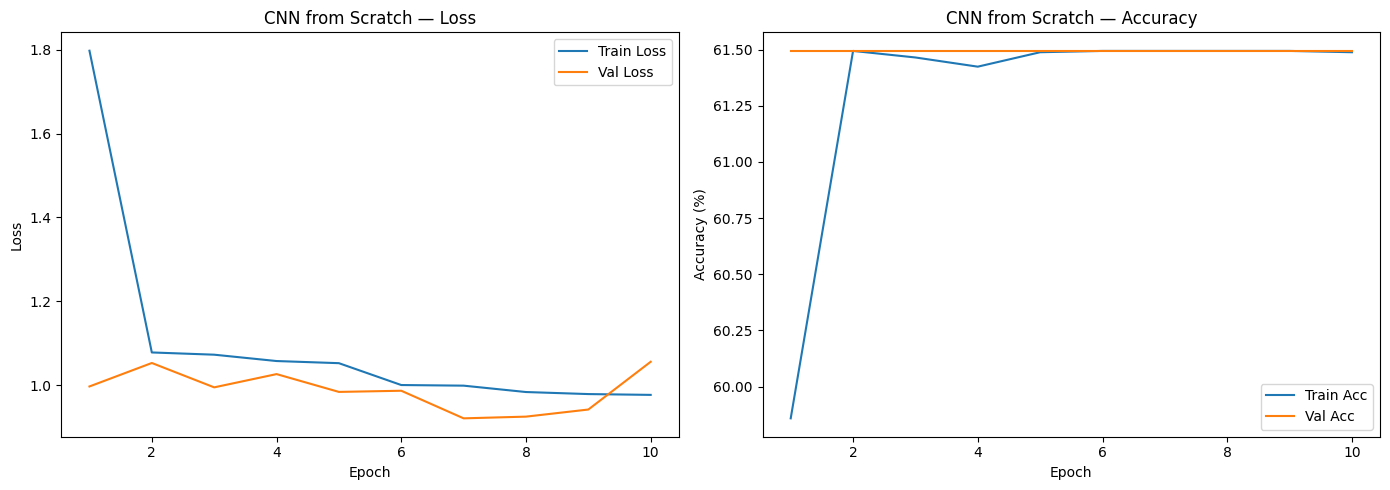

Saved.


In [11]:
# Cell 11 — Plot training curves
import matplotlib.pyplot as plt

epochs_range = range(1, 11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], label='Val Loss')
ax1.set_title('CNN from Scratch — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, history['train_acc'], label='Train Acc')
ax2.plot(epochs_range, history['val_acc'], label='Val Acc')
ax2.set_title('CNN from Scratch — Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('scratch_cnn_curves.png', dpi=150)
plt.show()
print("Saved.")

In [12]:
# Cell 12 — EfficientNet B0 transfer learning
import torchvision.models as models

def get_efficientnet(num_classes=5):
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')

    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier head with our own
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )

    return model

transfer_model = get_efficientnet(num_classes=5).to(device)

# Verify
dummy = torch.randn(2, 3, 224, 224).to(device)
out = transfer_model(dummy)
print(f"Output shape: {out.shape}")

# Count trainable params
trainable = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in transfer_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 173MB/s]


Output shape: torch.Size([2, 5])
Trainable params: 6,405 / 4,013,953


In [13]:
# Cell 13 — Optimizer for transfer model
transfer_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, transfer_model.parameters()),
    lr=1e-3
)
transfer_scheduler = optim.lr_scheduler.StepLR(transfer_optimizer, step_size=5, gamma=0.5)

print("Transfer model training setup done")
print("Only classifier head weights will be updated")


Transfer model training setup done
Only classifier head weights will be updated


In [14]:
# Cell 14 — Train EfficientNet
transfer_history = train_model(
    transfer_model,
    train_loader,
    val_loader,
    criterion,
    transfer_optimizer,
    transfer_scheduler,
    epochs=10
)

Epoch [1/10] Train Loss: 0.9249 Acc: 66.66% | Val Loss: 0.8795 Acc: 67.45%
Epoch [2/10] Train Loss: 0.8511 Acc: 69.12% | Val Loss: 0.8709 Acc: 68.53%
Epoch [3/10] Train Loss: 0.8364 Acc: 69.42% | Val Loss: 0.8253 Acc: 70.61%
Epoch [4/10] Train Loss: 0.8369 Acc: 69.57% | Val Loss: 0.8180 Acc: 70.40%
Epoch [5/10] Train Loss: 0.8340 Acc: 69.56% | Val Loss: 0.8306 Acc: 70.33%
Epoch [6/10] Train Loss: 0.8233 Acc: 69.90% | Val Loss: 0.8133 Acc: 70.98%
Epoch [7/10] Train Loss: 0.8136 Acc: 70.19% | Val Loss: 0.8010 Acc: 71.64%
Epoch [8/10] Train Loss: 0.8160 Acc: 70.35% | Val Loss: 0.8192 Acc: 70.65%
Epoch [9/10] Train Loss: 0.8117 Acc: 70.62% | Val Loss: 0.7814 Acc: 71.96%
Epoch [10/10] Train Loss: 0.8064 Acc: 70.52% | Val Loss: 0.8064 Acc: 71.00%


In [15]:
# Cell 15 — Unfreeze backbone and fine-tune entire network
# Unfreeze all layers
for param in transfer_model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
print(f"Trainable params now: {trainable:,}")

# Lower lr — backbone needs gentle updates, not aggressive ones
finetune_optimizer = optim.Adam(transfer_model.parameters(), lr=1e-4)
finetune_scheduler = optim.lr_scheduler.StepLR(finetune_optimizer, step_size=5, gamma=0.5)

finetune_history = train_model(
    transfer_model,
    train_loader,
    val_loader,
    criterion,
    finetune_optimizer,
    finetune_scheduler,
    epochs=10
)


Trainable params now: 4,013,953
Epoch [1/10] Train Loss: 0.6647 Acc: 75.89% | Val Loss: 0.5617 Acc: 80.47%
Epoch [2/10] Train Loss: 0.5289 Acc: 81.05% | Val Loss: 0.5184 Acc: 82.29%
Epoch [3/10] Train Loss: 0.4748 Acc: 82.84% | Val Loss: 0.4805 Acc: 83.48%
Epoch [4/10] Train Loss: 0.4314 Acc: 84.42% | Val Loss: 0.4795 Acc: 83.46%
Epoch [5/10] Train Loss: 0.3950 Acc: 85.90% | Val Loss: 0.4696 Acc: 84.28%
Epoch [6/10] Train Loss: 0.3490 Acc: 87.29% | Val Loss: 0.4708 Acc: 84.67%
Epoch [7/10] Train Loss: 0.3297 Acc: 88.10% | Val Loss: 0.4583 Acc: 85.09%
Epoch [8/10] Train Loss: 0.3162 Acc: 88.61% | Val Loss: 0.4656 Acc: 85.09%
Epoch [9/10] Train Loss: 0.2941 Acc: 89.54% | Val Loss: 0.4620 Acc: 85.28%
Epoch [10/10] Train Loss: 0.2830 Acc: 89.43% | Val Loss: 0.4686 Acc: 84.86%


In [16]:
# Cell 16 — Save best model
torch.save(transfer_model.state_dict(), '/content/efficientnet_finetuned.pth')
print("Model saved")

Model saved


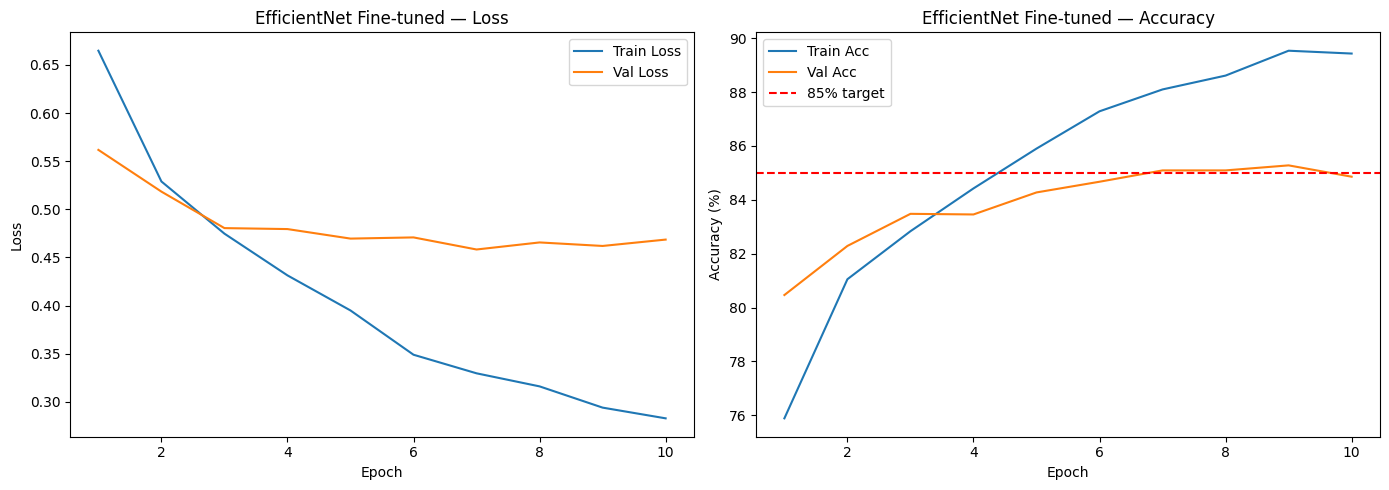

Saved.


In [17]:
# Cell 17 — Plot fine-tune training curves
epochs_range = range(1, 11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, finetune_history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, finetune_history['val_loss'], label='Val Loss')
ax1.set_title('EfficientNet Fine-tuned — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, finetune_history['train_acc'], label='Train Acc')
ax2.plot(epochs_range, finetune_history['val_acc'], label='Val Acc')
ax2.axhline(y=85, color='r', linestyle='--', label='85% target')
ax2.set_title('EfficientNet Fine-tuned — Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('efficientnet_curves.png', dpi=150)
plt.show()
print("Saved.")

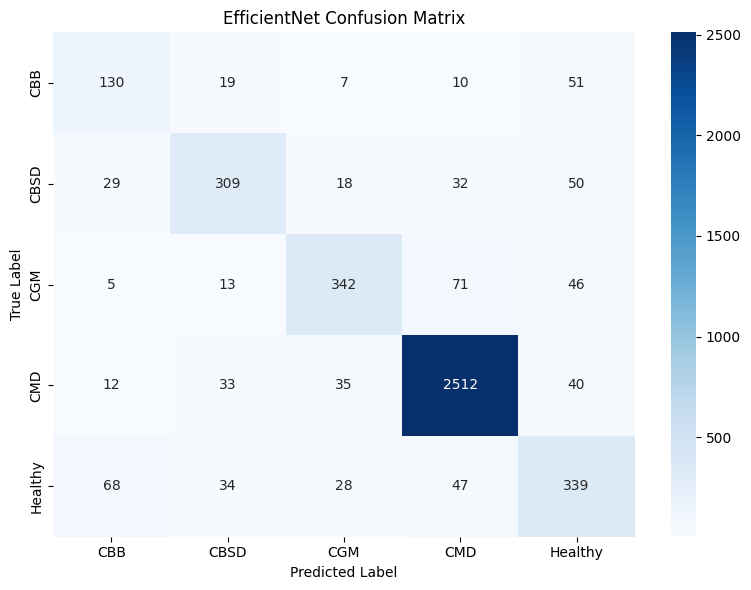


Classification Report:
              precision    recall  f1-score   support

         CBB       0.53      0.60      0.56       217
        CBSD       0.76      0.71      0.73       438
         CGM       0.80      0.72      0.75       477
         CMD       0.94      0.95      0.95      2632
     Healthy       0.64      0.66      0.65       516

    accuracy                           0.85      4280
   macro avg       0.73      0.73      0.73      4280
weighted avg       0.85      0.85      0.85      4280



In [18]:
# Cell 18 — Confusion matrix + per-class metrics
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get all predictions on val set
transfer_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = transfer_model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Class names
class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('EfficientNet Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Per-class metrics
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))